# Tutorial 6: Sequence Interpretation with In-Silico Mutagenesis

This tutorial uses saturation mutagenesis to investigate which nucleotides in the **IRF4 enhancer** (`chr6:396072-396572`) support its predicted activity in melanocytic (**MEL**) cells. IRF4 is part of the melanocytic regulatory program, making this enhancer a useful example of how sequence features can contribute to cell-state-specific regulation.

In-silico mutagenesis (ISM) systematically replaces every nucleotide with A, C, G, and T and runs each mutated sequence through the model. deepSCENIC first predicts the TF-to-region interaction strengths encoded by each sequence. It then weights those predictions by the mean latent TF activity of the selected cell class and sums across TFs to obtain a class-specific enhancer activity score.

Each reported value is `mutant activity - reference activity`. Negative scores indicate substitutions predicted to reduce enhancer activity in MEL cells, positive scores indicate substitutions predicted to increase it, and values near zero indicate little predicted effect. This analysis therefore connects the enhancer's nucleotide sequence to the regulatory state learned for a particular cell population.

## Setup

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

import deepscenic as ds

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
data_dir = "/data/groups/vib.ai/stein.aerts/gpartel/data/MM_lines_demo/"
genome_path = "/data/groups/vib.ai/stein.aerts/gpartel/resources/hg38.fa"

mdata = ds.read(data_dir + "preprocessed_data.h5mu")
model = ds.tl.load_model(data_dir + "checkpoints/deepscenic_model.pt", device=device)
ds.register_genome(genome_path)

deepscenic.io - INFO - Loaded /data/groups/vib.ai/stein.aerts/gpartel/data/MM_lines_demo/preprocessed_data.h5mu: 936 cells, 12109 genes, 288643 regions
2026-08-18 12:21:36.094726: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-18 12:21:36.105028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787048496.114547 1553951 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787048496.117317 1553951 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been re

## Mutagenize the IRF4 enhancer for MEL cells

The requested 500 bp enhancer is centered within the model's 640 bp sequence context so that every mutant is evaluated with the same surrounding DNA. The selected MEL cells provide the regulatory context: their mean latent TF activities determine how strongly each sequence-derived TF prediction contributes to the final enhancer score.

If latent TF activities are already stored by `ds.tl.to_latent`, the function reuses them. Otherwise, it computes the required TF encoder output directly from the RNA modality.

In [4]:
irf4_ism = ds.tl.in_silico_mutagenesis(
    model,
    mdata,
    region="chr6:396072-396572",
    class_key="cell_state",
    class_label="MEL",
    batch_size=128,
    device=device,
)

print("Model sequence interval:", irf4_ism.sequence_region)
print("Reference MEL activity:", irf4_ism.baseline_score)
irf4_ism.scores.shape

Model sequence interval: chr6:396002-396642
Reference MEL activity: 84.47080993652344


(640, 4)

## Visualize mutation effects

The heatmap contains one column per sequence position and one row for each nucleotide that can be introduced. Color represents the change in predicted MEL-specific enhancer activity. The reference nucleotide is not a mutation, so its entry is set to zero.

Vertical clusters of strong negative values identify positions where several alternative bases disrupt the prediction. Short groups of sensitive positions can point to sequence patterns used by the model, such as transcription-factor binding sites.

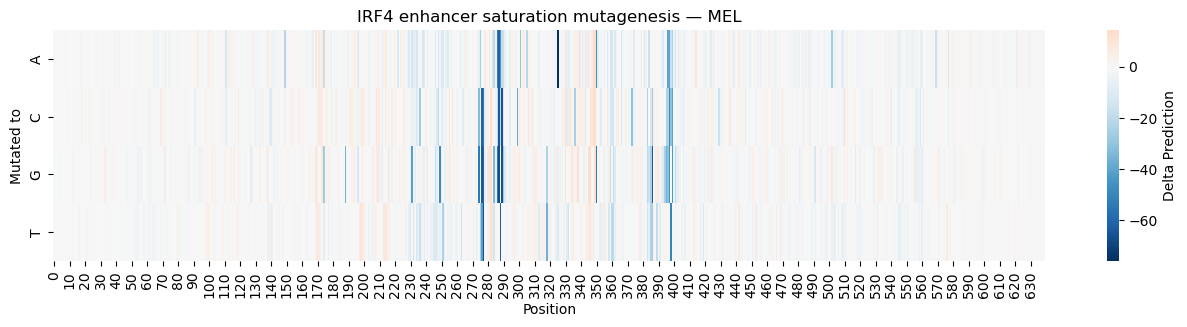

In [5]:
ds.pl.ism_heatmap(
    irf4_ism.scores,
    title="IRF4 enhancer saturation mutagenesis — MEL",
    figsize=(16, 3),
)

## Reference-sequence attribution logo

The attribution logo assigns each position's mean disruptive effect to its reference nucleotide. Letter height and direction summarize how strongly the reference base supports or opposes the predicted MEL-specific enhancer activity.

The two visualizations answer related but distinct questions: the heatmap shows the predicted consequence of each specific substitution, whereas the logo highlights the reference sequence at the most influential positions.

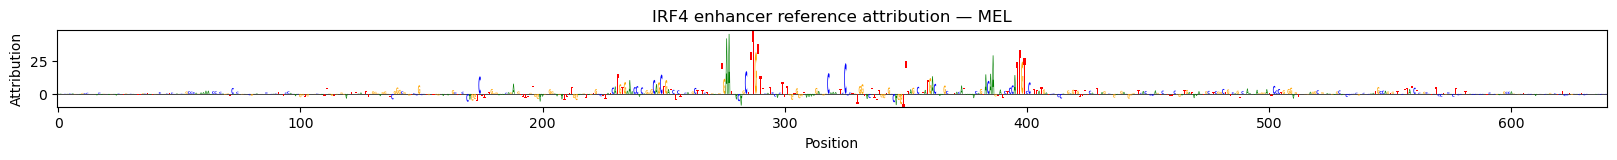

In [6]:
position_importance = -irf4_ism.scores.mean(axis=1)
base_index = {base: i for i, base in enumerate("ACGT")}
reference_attribution = np.zeros_like(irf4_ism.scores)
for position, base in enumerate(irf4_ism.sequence):
    if base in base_index:
        reference_attribution[position, base_index[base]] = position_importance[position]

ds.pl.logo_attribution(
    reference_attribution,
    title="IRF4 enhancer reference attribution — MEL",
    figsize=(20, 1),
)

## Compare with the MES cell class

The sequence-derived TF-to-region predictions are the same for every cell class, but their contribution to enhancer activity changes with the class-specific TF activity profile. Repeating ISM for mesenchymal (**MES**) cells therefore tests whether the IRF4 enhancer sequence is interpreted differently outside the MEL regulatory state.

We summarize the MES mutation effects with the same reference-sequence attribution used above. The two logos are plotted on a shared vertical scale, so differences in letter height or direction directly reflect differences in the TF activities used to weight the sequence predictions.

In [7]:
irf4_ism_mes = ds.tl.in_silico_mutagenesis(
    model,
    mdata,
    region="chr6:396072-396572",
    class_key="cell_state",
    class_label="MES",
    batch_size=128,
    device=device,
)

print("Reference MES activity:", irf4_ism_mes.baseline_score)

Reference MES activity: 2.395631790161133


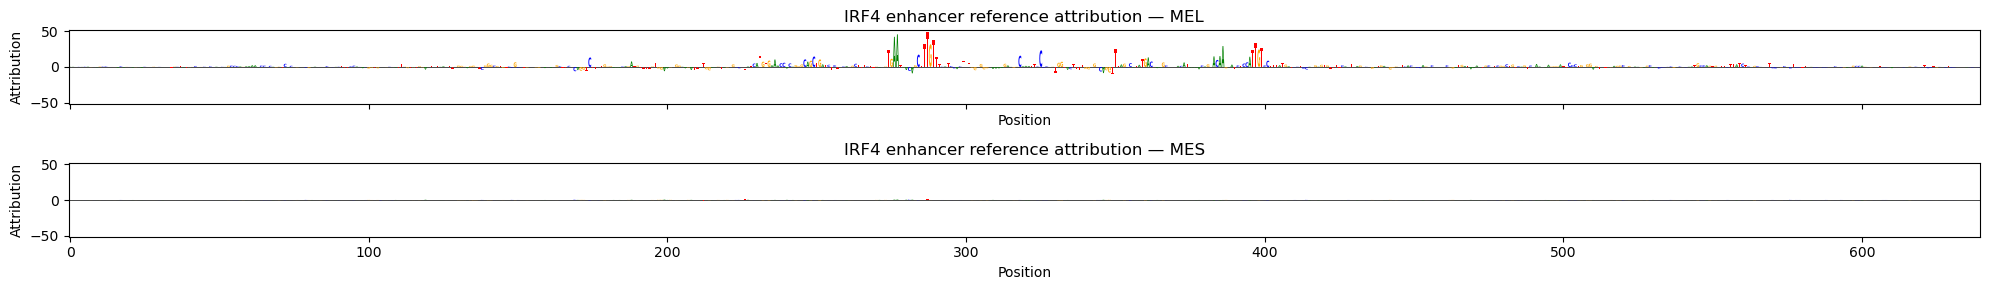

In [8]:
%matplotlib inline
mes_position_importance = -irf4_ism_mes.scores.mean(axis=1)
mes_reference_attribution = np.zeros_like(irf4_ism_mes.scores)
for position, base in enumerate(irf4_ism_mes.sequence):
    if base in base_index:
        mes_reference_attribution[position, base_index[base]] = mes_position_importance[position]

max_attribution = max(
    np.abs(reference_attribution).max(),
    np.abs(mes_reference_attribution).max(),
    1e-8,
)

fig, axes = plt.subplots(2, 1, figsize=(20, 3), sharex=True)
ds.pl.logo_attribution(
    reference_attribution,
    ax=axes[0],
    title="IRF4 enhancer reference attribution — MEL",
    show=False,
)
ds.pl.logo_attribution(
    mes_reference_attribution,
    ax=axes[1],
    title="IRF4 enhancer reference attribution — MES",
    show=False,
)
for ax in axes:
    ax.set_ylim(-1.05 * max_attribution, 1.05 * max_attribution)
plt.tight_layout()
plt.show()

## Interpretation

Strong negative mutation scores mark substitutions predicted to reduce IRF4 enhancer activity in MEL cells. A convincing candidate regulatory element will often appear as a compact run of sequence-sensitive positions rather than as a single isolated base. These patterns can be compared with known TF motifs to propose which factors may recognize the sequence.

The cell-class weighting is important: repeating the analysis with another `class_label` can reveal whether the same sequence is interpreted differently in another regulatory state. The result reflects both the sequence model's predicted TF interactions and the TF activities learned from the selected cells.

ISM scores are model explanations rather than experimental measurements. They prioritize bases and motifs for follow-up, but causal effects should be confirmed with independent motif evidence or targeted perturbation assays.